In [1]:
import numpy as np
import pandas as pd
import utils
import pickle
import time

from matplotlib import pyplot as plt
from scipy.stats import loguniform
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import validation_curve, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline

In [2]:
# Get the cleaned dataset
with open(f'data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

In [3]:
# Create a tuning subset
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Scale the target in tuning set
scaler_y = MinMaxScaler()
y_tune_scaled = scaler_y.fit_transform(y_tune.values.reshape(-1, 1)).ravel()

# Build a Pipeline (scaler + model)
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('mlp', MLPRegressor(solver='adam', max_iter=1000, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1, random_state=42))
])

# Define the hyperparameter search space
mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64), (64, 32), (128, 64, 32), (64, 32, 16)],
    'mlp__learning_rate_init': [1e-5, 1e-4, 1e-3, 1e-2],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [1e-6, 1e-5, 1e-4, 1e-3]
}

# Run the search using custom function
mlp_search, best_params, best_score = utils.optimize_hyper_params(mlp_pipeline, X_tune, y_tune, mlp_param_grid, 'grid')

# Print the metrics
print("\nBEST PARAMETERS: ", best_params)
print(f"BEST CV RMSE:    {-best_score:.16f}")

----- Running GridSearchCV -----
Fitting 3 folds for each of 128 candidates, totalling 384 fits
Total Runtime: 3.6873 minutes

BEST PARAMETERS:  {'mlp__activation': 'relu', 'mlp__alpha': 1e-06, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
BEST CV RMSE:    0.0228588835646709


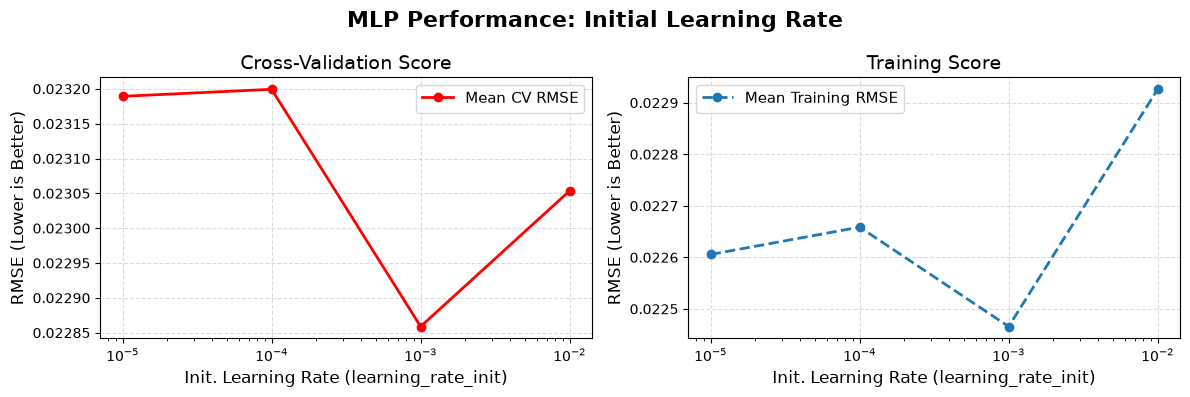

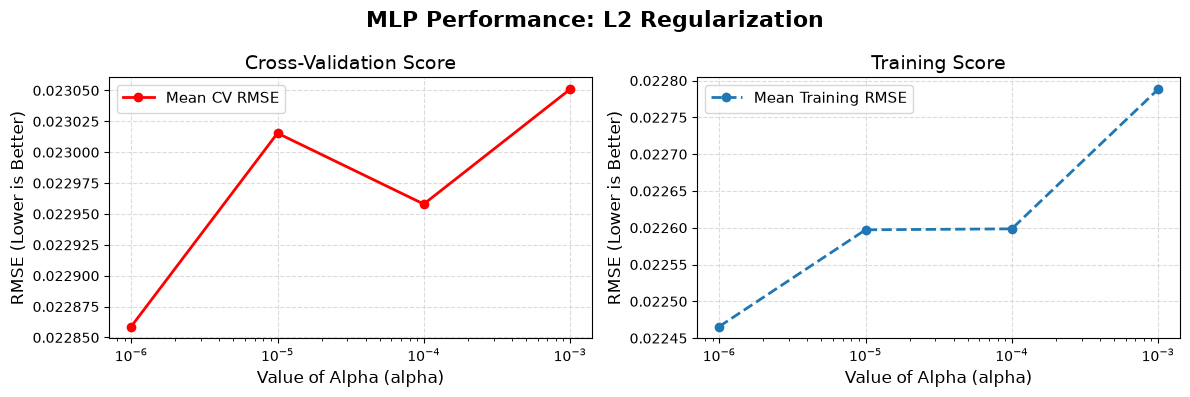

In [4]:
# Plot RMSE vs. Initial Learning Rate
utils.plot_side_by_side_diagnostics(
    search=mlp_search, 
    param_name='mlp__learning_rate_init', 
    suptitle='MLP Performance: Initial Learning Rate',
    xlabel_text='Init. Learning Rate (learning_rate_init)',
    log=True
)

# Plot RMSE vs. L2 Regularization
utils.plot_side_by_side_diagnostics(
    search=mlp_search, 
    param_name='mlp__alpha', 
    suptitle='MLP Performance: L2 Regularization',
    xlabel_text='Value of Alpha (alpha)',
    log=True
)

In [5]:
# Initialize the two different scalers
scaler_X = StandardScaler()
scaler_y = MinMaxScaler()

# Scale the features
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)

# Scale the targets
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()

In [6]:
# Train a new model with the optimial hyperparameters on the full training set
clean_params = {key.replace('mlp__', ''): value for key, value in best_params.items()}
mlp_final = MLPRegressor(**clean_params, max_iter=1000, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1, random_state=42)
mlp_final.fit(X_train_scaled, y_train_scaled)

# Make predictions on the validation set
scaled_predictions = mlp_final.predict(X_val_scaled)

# Untransform the predictions
z_pred_val = scaler_y.inverse_transform(scaled_predictions.reshape(-1, 1)).ravel()

# Calculate and print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val, y_val):.16f}")
print("-" * 36)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0248831551638856
Bias:             0.0001185453365906
NMAD:             0.0161584019660950
------------------------------------


In [7]:
# TESTING THE FINAL MODEL
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params}")
print("=" * 36 + "\n")

# Combine train and val data since we don't need the val
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

# Train the final model on the now bigger training set
mlp_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 

# Make predictions on the test set
z_pred_test = mlp_final.predict(np.array(X_test))

# Calculate and print the final metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_test, y_test):.16f}")
print(f"Bias:             {utils.bias(z_pred_test, y_test):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_test, y_test):.16f}")
print("-" * 36)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'mlp__activation': 'relu', 'mlp__alpha': 1e-06, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0244690301219414
Bias:             -0.0003825587045867
NMAD:             0.0161926001310349
------------------------------------
